# Webpage content preprocessing

Because of the characterstics of web archive data, preprocessing of webpage content is important to reduce the duplicate content and will improve the performance of semantic search.

The current workflow is as follows:
1. Load the raw HTML content extracted from the web archive payloads (removing the HTML boilerplate and focused on main content part).
2. Embedding the content and conduct similarity comparison for addressing semantic differences between snapshots.
3. Filter the new content (new_or_changed) webpages for building the vector database.

## Preprocessing with boilerplate removal

In [2]:
import os
import pandas as pd
import wa_nlnz_toolkit as want
from glob import glob
from tqdm import tqdm

In [99]:
# cdx_files = glob(os.path.join(res_folder, "covid19_warc/**/*.cdx"), recursive=True)
# warc_files = glob(os.path.join(res_folder, "covid19_warc/**/*.warc.gz"), recursive=True)
# print(f"Found {len(cdx_files)} CDX files.")
# print(f"Found {len(warc_files)} WARC files.")


# # Helper function to locate a specific WARC file in the folder
# def find_warc_file_path(warc_file):
#     for warc_file_path in warc_files:
#         if warc_file in warc_file_path:
#             return warc_file_path
#     return None

In [2]:
# Define S3 bucket and folder containing the archive data
bucket_name = "ndha-public-data-ap-southeast-2"
folder_prefix = "iPRES-2025/sample-data/covid19.govt.nz/"

# List all files in the S3 bucket folder
all_files = want.list_s3_files(bucket_name, folder_prefix)

# Filter for CDX index files
cdx_files = [f for f in all_files if f.endswith(".cdx")]

# Display the total number of crawls in the dataset
print(f"In total, there are {len(cdx_files)} crawls in the sample dataset.")


# Helper function to locate a specific WARC file in the S3 bucket
def find_warc_file_path(warc_file):
    """Find the full S3 path for a given WARC filename.

    Args:
        warc_file (str): The WARC filename to search for

    Returns:
        str: Full S3 path if found, None otherwise
    """
    for s3_file in all_files:
        if warc_file in s3_file:
            warc_file_path = "s3://ndha-public-data-ap-southeast-2/" + s3_file
            return warc_file_path
    return None

In total, there are 42 crawls in the sample dataset.


In [20]:
# Process each CDX file
def extract_and_save_content(cdx_file, content_dir, boilerplate_removal_method):
    # Load CDX file data
    # df_cdx = pd.read_csv(cdx_file, sep=" ", skiprows=0)
    # # ignore last two columns
    # df_cdx = df_cdx.iloc[:, :-2]
    # df_cdx.columns = ["N", "b", "a", "m", "s", "k", "r", "M", "S", "V", "g"]

    df_cdx = want.load_cdx_file_from_s3(bucket_name, cdx_file)

    # Extract date from filename
    dt = cdx_file.split("/")[-2].split("_")[0]

    # Initialize lists to store content and URLs
    contents = []
    urls = []

    # Process each entry in the CDX file
    for idx in tqdm(range(len(df_cdx)), desc=f"Extracting contents for {dt}"):
        # Get WARC file and offset information
        warc_file = df_cdx.iloc[idx]["g"]
        offset = int(df_cdx.iloc[idx]["V"])

        # Extract HTML payload and text content
        html_payload = want.extract_payload(find_warc_file_path(warc_file), offset)

        # Default boilerplate removal and text extraction approach
        # Try other approaches and compare results if needed
        html_content = boilerplate_removal_method(html_payload)

        # Construct access URL for this capture
        url = "https://ndhadeliver.natlib.govt.nz/webarchive/{}/{}".format(
            df_cdx.iloc[idx]["b"], df_cdx.iloc[idx]["a"]
        )

        # Log URLs with no content extracted
        if (html_content == []) or (html_content == ""):
            print(f"No content extracted from: {url}")
        else:
            contents.append(html_content)
            urls.append(url)

    # Joint the content list into a single string for each entry (if it's a list of paragraphs)
    contents = [
        "\n\n".join(content) if isinstance(content, list) else content
        for content in contents
    ]

    # Store the data into a pandas DataFrame
    # NOTE: In practice, the Apache Parquet will be used for better performance and storage efficiency
    df_content = pd.DataFrame({"url": urls, "content": contents})

    # Ensure all content is string-type to avoid Arrow extension errors
    df_content["url"] = df_content["url"].astype(str)
    df_content["content"] = df_content["content"].astype(str)

    # Save the DataFrame to a Parquet file (optional, for intermediate storage)
    df_content.to_parquet(
        os.path.join(content_dir, f"covid19_content_{dt}.parquet"),
        index=False,
        engine="pyarrow",  # Explicitly set the engine
    )

    # # Remove duplicate content entries and corresponding URLs
    # content_valid = []
    # url_valid = []
    # for content, url in zip(contents, urls):
    #     if type(content) == list:
    #         content_joined = " ".join(content)
    #     else:
    #         content_joined = content

    #     if content_joined not in content_valid:
    #         content_valid.append(content_joined)
    #         url_valid.append(url)

    # Save cleaned content to text files
    # with open(os.path.join(content_dir, f"covid19_raw_content_{dt}.txt"), "w") as f:
    #     f.write("\n".join(content_valid))

    # with open(os.path.join(url_dir, f"covid19_url_{dt}.txt"), "w") as f:
    #     f.write("\n".join(url_valid))

### Default extraction

In [ ]:
res_folder = "./sample_data"


# Create directories for storing extracted content
content_dir = os.path.join(res_folder, "covid19_corpus/raw_default")
# url_dir = os.path.join(res_folder, "covid19_corpus/raw_default/url")

# Ensure directories exist
os.makedirs(content_dir, exist_ok=True)
# os.makedirs(url_dir, exist_ok=True)

extract_and_save_content(
    cdx_files[0],
    content_dir,
    # url_dir,
    boilerplate_removal_method=want.extract_content_html,
)

### Simple HTML tags removal

In [12]:
from html_payload import clean_html_to_text


res_folder = "./sample_data"


# Create directories for storing extracted content
content_dir = os.path.join(res_folder, "covid19_corpus/raw_tag_removal")
# url_dir = os.path.join(res_folder, "covid19_corpus/raw_default/url")

# Ensure directories exist
os.makedirs(content_dir, exist_ok=True)
# os.makedirs(url_dir, exist_ok=True)

extract_and_save_content(
    cdx_files[0],
    content_dir,
    # url_dir,
    boilerplate_removal_method=clean_html_to_text,
)

Extracting contents for 2020-03-19: 100%|██████████| 43/43 [00:09<00:00,  4.38it/s]


### markitdown

https://github.com/microsoft/markitdown

Markdown is extremely close to plain text, with minimal markup or formatting, but still provides a way to represent important document structure. Mainstream LLMs, such as OpenAI's GPT-4o, natively "speak" Markdown, and often incorporate Markdown into their responses unprompted. This suggests that they have been trained on vast amounts of Markdown-formatted text, and understand it well. As a side benefit, Markdown conventions are also highly token-efficient.

In [8]:
# !pip install -q markitdown fastparquet pyarrow

  Obtaining dependency information for markitdown from https://files.pythonhosted.org/packages/b1/8b/fd7e042455a829a1ede0bc8e9e3061aa6c7c4cf745385526ef62ff1b5a5b/markitdown-0.1.5-py3-none-any.whl.metadata
  Obtaining dependency information for defusedxml from https://files.pythonhosted.org/packages/07/6c/aa3f2f849e01cb6a001cd8554a88d4c77c5c1a31c95bdf1cf9301e6d9ef4/defusedxml-0.7.1-py2.py3-none-any.whl.metadata
  Obtaining dependency information for magika~=0.6.1 from https://files.pythonhosted.org/packages/c4/03/5ed859be502903a68b7b393b17ae0283bf34195cfcca79ce2dc25b9290e7/magika-0.6.3-py3-none-manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for markdownify from https://files.pythonhosted.org/packages/43/ce/f1e3e9d959db134cedf06825fae8d5b294bd368aacdd0831a3975b7c4d55/markdownify-1.2.2-py3-none-any.whl.metadata
  Obtaining dependency information for click>=8.1.7 from https://files.pythonhosted.org/packages/e4/20/71885d8b97d4f3dde17b1fdb92dbd4908b00541c5a337978713728

In [13]:
import io
from markitdown import MarkItDown

md = MarkItDown()


def extract_content_with_markitdown(html_payload):
    # Check if it's a string, if so, convert to bytes
    if isinstance(html_payload, str):
        html_payload = html_payload.encode("utf-8")

    stream = io.BytesIO(html_payload)
    result = md.convert_stream(stream, extension=".html")

    # Access the converted text
    return result.text_content

In [14]:
res_folder = "./sample_data"


# Create directories for storing extracted content
content_dir = os.path.join(res_folder, "covid19_corpus/raw_markitdown")

# Ensure directories exist
os.makedirs(content_dir, exist_ok=True)

extract_and_save_content(
    cdx_files[0],
    content_dir,
    boilerplate_removal_method=extract_content_with_markitdown,
)

Extracting contents for 2020-03-19: 100%|██████████| 43/43 [00:09<00:00,  4.42it/s]


### Trafilatura
https://github.com/adbar/trafilatura

In [83]:
# BUGFIX default trafilatura installation by installing lxml_html_clean explicitly
# !pip -q install trafilatura lxml_html_clean


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [16]:
from trafilatura import extract


def extract_content_trafilatura(html_payload):
    # Extract content using trafilatura
    html_content = extract(html_payload)

    # Replace \n with "--- Section Separator ---" to preserve section breaks
    # if html_content is not None:
    #     html_content = html_content.replace("\n", "--- Section Separator ---")

    return html_content

In [17]:
res_folder = "./sample_data"


# Create directories for storing extracted content
content_dir = os.path.join(res_folder, "covid19_corpus/raw_trafilatura")
# url_dir = os.path.join(res_folder, "covid19_corpus/raw_trafilatura/url")

# Ensure directories exist
os.makedirs(content_dir, exist_ok=True)
# os.makedirs(url_dir, exist_ok=True)

extract_and_save_content(
    cdx_files[0],
    content_dir,
    # url_dir,
    boilerplate_removal_method=extract_content_trafilatura,
)

Extracting contents for 2020-03-19: 100%|██████████| 43/43 [00:09<00:00,  4.47it/s]


### jusText

https://github.com/miso-belica/justext

In [88]:
# !pip install -q justext


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import justext


def extract_content_justext(html_payload):
    # Extract content using jusText
    paragraphs = justext.justext(html_payload, justext.get_stoplist("English"))
    html_content = "\n\n".join(
        [para.text for para in paragraphs if not para.is_boilerplate]
    )

    # if html_content is not None:
    #     html_content = html_content.replace("\n", "--- Section Separator ---")

    return html_content

In [19]:
res_folder = "./sample_data"


# Create directories for storing extracted content
content_dir = os.path.join(res_folder, "covid19_corpus/raw_justext")
# url_dir = os.path.join(res_folder, "covid19_corpus/raw_justext/url")

# Ensure directories exist
os.makedirs(content_dir, exist_ok=True)
# os.makedirs(url_dir, exist_ok=True)

extract_and_save_content(
    cdx_files[0],
    content_dir,
    # url_dir,
    boilerplate_removal_method=extract_content_justext,
)

Extracting contents for 2020-03-19:   5%|▍         | 2/43 [00:00<00:08,  5.05it/s]

No content extracted from: https://ndhadeliver.natlib.govt.nz/webarchive/20200318051827/https://covid19.govt.nz/help-and-advice/


Extracting contents for 2020-03-19:   7%|▋         | 3/43 [00:00<00:08,  4.71it/s]

No content extracted from: https://ndhadeliver.natlib.govt.nz/webarchive/20200318051834/https://covid19.govt.nz/help-and-advice/for-businesses-and-organisations/


Extracting contents for 2020-03-19:   9%|▉         | 4/43 [00:00<00:08,  4.55it/s]

...

Extracting contents for 2020-03-19:  93%|█████████▎| 40/43 [00:08<00:00,  4.44it/s]

No content extracted from: https://ndhadeliver.natlib.govt.nz/webarchive/20200318052017/https://covid19.govt.nz/latest-updates/major-steps-taken-to-protect-new-zealanders-from-covid-19/


Extracting contents for 2020-03-19:  95%|█████████▌| 41/43 [00:08<00:00,  4.48it/s]

No content extracted from: https://ndhadeliver.natlib.govt.nz/webarchive/20200318051949/https://covid19.govt.nz/new-zealand-sign-language/


Extracting contents for 2020-03-19: 100%|██████████| 43/43 [00:09<00:00,  4.70it/s]


### Compare the results of different boilerplate removal methods and select the best one for our use case.

In [9]:
# Get all URLs from the 2020-03-19 crawl using the default extraction method
df_default = pd.read_parquet(
    "./sample_data/covid19_corpus/raw_default/covid19_content_2020-03-19.parquet"
)
print(df_default["url"])

0                                                                                https://ndhadeliver.natlib.govt.nz/webarchive/20200318051641/https://covid19.govt.nz/
1                                                                https://ndhadeliver.natlib.govt.nz/webarchive/20200318051827/https://covid19.govt.nz/help-and-advice/
2                               https://ndhadeliver.natlib.govt.nz/webarchive/20200318051834/https://covid19.govt.nz/help-and-advice/for-businesses-and-organisations/
3       https://ndhadeliver.natlib.govt.nz/webarchive/20200318051906/https://covid19.govt.nz/help-and-advice/for-businesses-and-organisations/employers-including-rse/
4         https://ndhadeliver.natlib.govt.nz/webarchive/20200318051916/https://covid19.govt.nz/help-and-advice/for-businesses-and-organisations/physical-contact-jobs/
5                  https://ndhadeliver.natlib.govt.nz/webarchive/20200318051913/https://covid19.govt.nz/help-and-advice/for-businesses-and-organisations/sole-traders

In [10]:
# Select one URL for comparison
url = "https://ndhadeliver.natlib.govt.nz/webarchive/20200318051641/https://covid19.govt.nz/"
# url = "https://ndhadeliver.natlib.govt.nz/webarchive/20200318052121/https://covid19.govt.nz/help-and-advice/for-everyone/vulnerable-people/"

In [11]:
# Load extracted content tables
parquet_paths = {
    "default": "./sample_data/covid19_corpus/raw_default/covid19_content_2020-03-19.parquet",
    "tag_removal": "./sample_data/covid19_corpus/raw_tag_removal/covid19_content_2020-03-19.parquet",
    "trafilatura": "./sample_data/covid19_corpus/raw_trafilatura/covid19_content_2020-03-19.parquet",
    "justext": "./sample_data/covid19_corpus/raw_justext/covid19_content_2020-03-19.parquet",
    "markitdown": "./sample_data/covid19_corpus/raw_markitdown/covid19_content_2020-03-19.parquet",
}

dfs = {name: pd.read_parquet(path) for name, path in parquet_paths.items()}

# Keep explicit dataframe names for readability / downstream cells
df_default = dfs["default"]
df_tag_removal = dfs["tag_removal"]
df_trafilatura = dfs["trafilatura"]
df_justext = dfs["justext"]
df_markitdown = dfs["markitdown"]


def get_content_by_url(df, target_url, fallback):
    matches = df.loc[df["url"].eq(target_url), "content"]
    return matches.iat[0] if not matches.empty else fallback


content_default = get_content_by_url(
    df_default, url, "No content extracted with default method."
)
content_tag_removal = get_content_by_url(
    df_tag_removal, url, "No content extracted with tag removal method."
)
content_trafilatura = get_content_by_url(
    df_trafilatura, url, "No content extracted with trafilatura method."
)
content_justext = get_content_by_url(
    df_justext, url, "No content extracted with justext method."
)
content_markitdown = get_content_by_url(
    df_markitdown, url, "No content extracted with markitdown method."
)

In [15]:
# Display URL title + four columns side by side in a scrollable container
from html import escape
from IPython.display import display, HTML
import difflib
import re


def tokenize(text):
    # Split into words but keep punctuation
    return re.findall(r"\w+|[^\w\s]", text, re.UNICODE)


def highlight_surviving_text(a, b):
    a_words = tokenize(a)
    b_words = tokenize(b)

    matcher = difflib.SequenceMatcher(None, a_words, b_words)

    result = []

    for opcode, a0, a1, b0, b1 in matcher.get_opcodes():
        segment = " ".join(a_words[a0:a1])

        if opcode == "equal":
            # highlight text that exists
            result.append(f"<mark>{segment}</mark>")
        else:
            # leave remaining text unhighlighted
            result.append(segment)

    return "".join(result)


html_output = f"""
<div style="margin-bottom: 12px;">
    <h2 style="margin: 0 0 12px 0;">HTML Page: {escape(url)}</h2>
</div>

<div style="display: flex; gap: 20px; overflow-x: auto;">
    <div style="flex: 1; min-width: 300px;">
        <h3>Default</h3>
        <pre style="white-space: pre-wrap; word-wrap: break-word;">{highlight_surviving_text(content_markitdown, content_default)}</pre>
    </div>
    <div style="flex: 1; min-width: 300px;">
        <h3>Trafilatura</h3>
        <pre style="white-space: pre-wrap; word-wrap: break-word;">{highlight_surviving_text(content_markitdown, content_trafilatura)}</pre>
    </div>
    <div style="flex: 1; min-width: 300px;">
        <h3>Justext</h3>
        <pre style="white-space: pre-wrap; word-wrap: break-word;">{highlight_surviving_text(content_markitdown, content_justext)}</pre>
    </div>
</div>
"""

display(HTML(html_output))

# save the html output to a file for better readability
res_folder = "./sample_data"
with open(os.path.join(res_folder, "content_comparison.html"), "w") as f:
    f.write(html_output)

## Preprocessing all snapshots

Now we'll extend the text extraction process to all crawls in the dataset.

By default we will use the default extraction method provided in the wa-nlnz-toolkit. However, we can easily switch to other methods by changing the `boilerplate_removal_method` parameter in the `extract_and_save_content` function.

In [51]:
res_folder = "./sample_data"


# Create directories for storing extracted content
content_dir = os.path.join(res_folder, "covid19_corpus/raw_default")

# Ensure directories exist
os.makedirs(content_dir, exist_ok=True)

for cdx_file in cdx_files:
    extract_and_save_content(
        cdx_file,
        content_dir,
        boilerplate_removal_method=want.extract_content_html,
    )

Extracting contents for 2020-05-11:   5%|▍         | 17/347 [00:04<01:24,  3.88it/s]

No content extracted from: https://ndhadeliver.natlib.govt.nz/webarchive/20200508060631/https://covid19.govt.nz/businesses-and-employees/covid-19-financial-support-tool/


Extracting contents for 2020-05-11:  68%|██████▊   | 236/347 [01:03<00:28,  3.91it/s]

No content extracted from: https://ndhadeliver.natlib.govt.nz/webarchive/20200508061601/https://covid19.govt.nz/search


Extracting contents for 2020-05-11:  68%|██████▊   | 237/347 [01:04<00:35,  3.13it/s]

...

Extracting contents for 2023-12-14:  93%|█████████▎| 270/289 [01:18<00:05,  3.37it/s]

No content extracted from: https://ndhadeliver.natlib.govt.nz/webarchive/20231213000141/https://covid19.govt.nz/search


Extracting contents for 2023-12-14:  94%|█████████▍| 271/289 [01:18<00:05,  3.52it/s]

No content extracted from: https://ndhadeliver.natlib.govt.nz/webarchive/20231213012205/https://covid19.govt.nz/search/


Extracting contents for 2023-12-14: 100%|██████████| 289/289 [01:23<00:00,  3.47it/s]


## Deduplication using embedding similarity

In [2]:
import os
import re


# Reuse the extract_date function
def extract_date(fname):
    """Extract date in YYYY-MM-DD format from a filename.

    Args:
        fname: Filename string containing a date

    Returns:
        Date string in YYYY-MM-DD format or None if not found
    """
    match = re.search(r"(\d{4}-\d{2}-\d{2})", fname)
    return match.group(1) if match else None


# Configuration for vector database
res_folder = "./sample_data"
embedding_model = "all-MiniLM-L6-v2"  # Pre-trained embedding model
input_content_dir = os.path.join(
    res_folder, "covid19_corpus/raw_default"
)  # Directory with raw text files

### Similarity comparison and content filtering

In [4]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd


# -------------------------
# Load snapshot
# -------------------------
files_content = sorted(
    [f for f in os.listdir(input_content_dir) if f.endswith(".parquet")]
)

snapshot_pages = []
snapshot_urls = []
for file_content in files_content:
    # Load content file
    content_file_path = os.path.join(input_content_dir, file_content)

    lines = pd.read_parquet(content_file_path)["content"].tolist()
    urls = pd.read_parquet(content_file_path)["url"].tolist()

    # with open(content_file_path, encoding="utf-8") as f:
    #     lines = [line.strip() for line in f]

    # # Load url file
    # url_file_path = os.path.join(input_url_dir, file_url)
    # with open(url_file_path, encoding="utf-8") as f:
    #     urls = [line.strip() for line in f]

    snapshot_pages.append(lines)
    snapshot_urls.append(urls)

# -------------------------
# Model
# -------------------------
model = SentenceTransformer(embedding_model)


def embed_snapshots(snapshot_pages):
    """
    Embedding function for snapshots.
    """
    return model.encode(
        snapshot_pages, convert_to_numpy=True, normalize_embeddings=True
    )


# -------------------------
# Snapshot embeddings
# -------------------------
snapshot_embs = []
for snapshot_page in snapshot_pages:
    snapshot_embs.append(embed_snapshots(snapshot_page))


# -------------------------
# Semantic diff between snapshots
# -------------------------
results = []

for i in range(len(snapshot_embs)):
    prev = snapshot_embs[i - 1] if i > 0 else []
    curr = snapshot_embs[i]

    status_list = []

    for idx, emb in enumerate(curr):
        if len(prev) == 0:
            status_list.append(("new_or_changed", idx))
            continue

        sims = cosine_similarity([emb], prev)[0]
        best_sim = sims.max()

        if best_sim > 0.95:
            status = "unchanged"
        elif best_sim > 0.85:
            status = "slightly_updated"
        else:
            status = "new_or_changed"

        status_list.append((status, idx))

    results.append(status_list)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Display the results and analyze the effectiveness of the deduplication process

<Axes: title={'center': 'Web archive (covid19.govt.nz) page status'}, ylabel='Number of pages'>

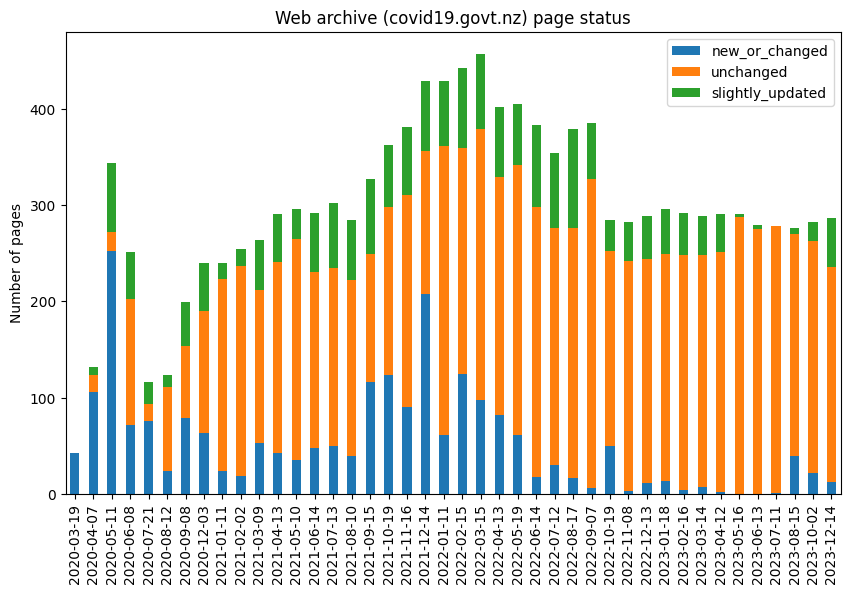

In [5]:
from collections import Counter
import pandas as pd


def count_statuses(data):
    """
    Counts the number of each status in a list of tuples,
    ignoring the second column.
    """
    # Generator expression extracts the first element (status) from each tuple
    return Counter(row[0] for row in data)


# Show variations of page status among snapshots
snapshot_dt = [extract_date(filename) for filename in files_content]

df_status_counts = pd.DataFrame(
    [count_statuses(result) for result in results], index=snapshot_dt
)
# df_status_counts = df_status_counts[["new_or_changed", "slightly_updated", "unchanged"]]

df_status_counts.plot.bar(
    stacked=True,
    title="Web archive (covid19.govt.nz) page status",
    figsize=(10, 6),
    ylabel="Number of pages",
)

### Filter new or changed webpages for building the vector database

In [6]:
def extract_changed_pages(
    snapshot_pages_all, snapshot_status_all, snapshot_urls_all, filter
):
    changed_pages = []

    # results[0] -> snapshots[1]
    for i, snapshot_status in enumerate(snapshot_status_all):
        snapshot_id = i
        snapshot_pages = snapshot_pages_all[snapshot_id]
        snapshot_urls = snapshot_urls_all[snapshot_id]

        for status, page_idx in snapshot_status:
            if status == filter:
                # ignore pages with little information (character length < 100)
                if len(snapshot_pages[page_idx]) < 100:
                    continue

                changed_pages.append(
                    {
                        "snapshot_id": snapshot_id,
                        "page_idx": page_idx,
                        "url": snapshot_urls[page_idx],
                        "text": snapshot_pages[page_idx],
                    }
                )
    return changed_pages


changed_pages = extract_changed_pages(
    snapshot_pages, results, snapshot_urls, "new_or_changed"
)

In [ ]:
# save to local as parquet for better readability and downstream processing
df_changed_pages = pd.DataFrame(changed_pages)
df_changed_pages.to_parquet(
    os.path.join(res_folder, "preprocessed_corpus.parquet"),
    index=False,
    engine="pyarrow",
)